In [203]:
import os
import sys
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))
from transformer_architecture_base import Decoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(DEVICE)

2.5.1
cuda


In [204]:
df = pd.read_csv("../data/preprocessed_data.csv")
df.head()

,City_id,Seq_id,Year,Month,Lat,Lon,Population_Density_per_SqKm,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),...,O3 (ug/m3),Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT
0,Canberra | Australia,24169,2014,1,-35.2931,149.1269,343.71,6.85,21.13,3.37,...,38.00,1.07,2.41,2.54,39.0,12.88,47.47,0.0051,0.77,7.80
1,Sydney | Australia,24169,2014,1,-33.8678,151.2100,3734.49,14.88,8.24,2.46,...,60.70,0.62,2.35,0.78,84.0,25.59,71.72,0.0055,0.69,7.42
2,Newcastle | Australia,24169,2014,1,-32.9167,151.7500,371.91,5.57,18.62,2.57,...,60.82,0.80,1.97,1.38,27.0,26.06,57.64,0.0042,1.17,12.21
3,Wollongong | Australia,24169,2014,1,-34.4331,150.8831,5.00,4.98,19.61,2.52,...,45.29,1.39,5.07,1.44,35.0,9.97,50.29,0.0025,1.16,4.09
4,Central Coast | Australia,24169,2014,1,-33.2992,151.1922,5.00,4.94,9.70,4.26,...,46.39,1.12,3.01,2.51,41.0,8.34,45.25,0.0041,1.33,5.44


In [205]:
df[df["City_id"] == "Sydney | Australia"]

,City_id,Seq_id,Year,Month,Lat,Lon,Population_Density_per_SqKm,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),...,O3 (ug/m3),Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT
1,Sydney | Australia,24169,2014,1,-33.8678,151.21,3734.49,14.88,8.24,2.46,...,60.70,0.62,2.35,0.78,84.0,25.59,71.72,0.0055,0.69,7.42
1746,Sydney | Australia,24170,2014,2,-33.8678,151.21,2731.00,5.47,17.22,4.13,...,45.80,0.91,3.59,1.25,25.0,25.09,41.12,0.0062,1.09,9.94
3491,Sydney | Australia,24171,2014,3,-33.8678,151.21,4343.07,2.18,11.49,4.35,...,19.01,0.72,2.79,2.00,24.0,24.72,25.88,0.0082,0.53,16.13
5236,Sydney | Australia,24172,2014,4,-33.8678,151.21,6323.33,9.42,16.74,11.03,...,30.63,0.69,2.63,1.67,47.0,11.10,60.16,0.0076,0.94,5.31
6981,Sydney | Australia,24173,2014,5,-33.8678,151.21,1998.30,8.93,11.03,5.65,...,44.90,0.51,1.79,0.69,38.0,28.12,40.77,0.0051,1.37,11.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242556,Sydney | Australia,24308,2025,8,-33.8678,151.21,4412.66,8.57,7.70,5.06,...,24.29,0.76,2.19,1.43,40.0,27.50,87.08,0.0044,1.37,7.90
244301,Sydney | Australia,24309,2025,9,-33.8678,151.21,4005.30,7.42,11.47,4.82,...,39.63,0.84,2.27,1.76,31.0,19.60,69.64,0.0049,0.59,9.18
246046,Sydney | Australia,24310,2025,10,-33.8678,151.21,4250.53,3.33,11.47,5.78,...,31.33,0.81,3.15,1.45,30.0,17.80,51.96,0.0058,1.08,12.82
247791,Sydney | Australia,24311,2025,11,-33.8678,151.21,4495.01,10.83,22.84,5.47,...,33.90,0.35,0.99,0.49,44.0,25.20,42.88,0.0049,1.12,14.55


# Data Processing

In [206]:
SEQ_LEN = 30
VAL_TIME = 12
TEST_TIME = 12
TEST_ONLY_ENITY = 45

### Train Val Test Splitting

In [207]:
from sklearn.model_selection import train_test_split

In [208]:
entities = df["City_id"].unique()

train_entities, test_entities = train_test_split(
    entities,
    test_size=TEST_ONLY_ENITY,
    random_state=42
)

test_df  = df[df["City_id"].isin(test_entities)]
df = df[df["City_id"].isin(train_entities)]

In [209]:
entity = df["City_id"].unique()
seq = df["Seq_id"].unique()
seq_start = np.arange(seq.min(), seq.max() - SEQ_LEN + 1, 1)
print(seq_start)
len(entity), len(seq), len(seq_start)

[24169 24170 24171 24172 24173 24174 24175 24176 24177 24178 24179 24180
 24181 24182 24183 24184 24185 24186 24187 24188 24189 24190 24191 24192
 24193 24194 24195 24196 24197 24198 24199 24200 24201 24202 24203 24204
 24205 24206 24207 24208 24209 24210 24211 24212 24213 24214 24215 24216
 24217 24218 24219 24220 24221 24222 24223 24224 24225 24226 24227 24228
 24229 24230 24231 24232 24233 24234 24235 24236 24237 24238 24239 24240
 24241 24242 24243 24244 24245 24246 24247 24248 24249 24250 24251 24252
 24253 24254 24255 24256 24257 24258 24259 24260 24261 24262 24263 24264
 24265 24266 24267 24268 24269 24270 24271 24272 24273 24274 24275 24276
 24277 24278 24279 24280 24281 24282]


(1700, 144, 114)

In [210]:
train_seq = seq_start[:- VAL_TIME - TEST_TIME]
val_seq = seq_start[- VAL_TIME - TEST_TIME: - TEST_TIME]
test_seq = seq_start[- TEST_TIME:]
train_seq, val_seq, test_seq

(array([24169, 24170, 24171, 24172, 24173, 24174, 24175, 24176, 24177,
        24178, 24179, 24180, 24181, 24182, 24183, 24184, 24185, 24186,
        24187, 24188, 24189, 24190, 24191, 24192, 24193, 24194, 24195,
        24196, 24197, 24198, 24199, 24200, 24201, 24202, 24203, 24204,
        24205, 24206, 24207, 24208, 24209, 24210, 24211, 24212, 24213,
        24214, 24215, 24216, 24217, 24218, 24219, 24220, 24221, 24222,
        24223, 24224, 24225, 24226, 24227, 24228, 24229, 24230, 24231,
        24232, 24233, 24234, 24235, 24236, 24237, 24238, 24239, 24240,
        24241, 24242, 24243, 24244, 24245, 24246, 24247, 24248, 24249,
        24250, 24251, 24252, 24253, 24254, 24255, 24256, 24257, 24258]),
 array([24259, 24260, 24261, 24262, 24263, 24264, 24265, 24266, 24267,
        24268, 24269, 24270]),
 array([24271, 24272, 24273, 24274, 24275, 24276, 24277, 24278, 24279,
        24280, 24281, 24282]))

### Normalization

In [211]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [212]:
scaler_seq = set(seq[:- VAL_TIME - TEST_TIME])
scaler_seq

{np.int64(24169),
 np.int64(24170),
 np.int64(24171),
 np.int64(24172),
 np.int64(24173),
 np.int64(24174),
 np.int64(24175),
 np.int64(24176),
 np.int64(24177),
 np.int64(24178),
 np.int64(24179),
 np.int64(24180),
 np.int64(24181),
 np.int64(24182),
 np.int64(24183),
 np.int64(24184),
 np.int64(24185),
 np.int64(24186),
 np.int64(24187),
 np.int64(24188),
 np.int64(24189),
 np.int64(24190),
 np.int64(24191),
 np.int64(24192),
 np.int64(24193),
 np.int64(24194),
 np.int64(24195),
 np.int64(24196),
 np.int64(24197),
 np.int64(24198),
 np.int64(24199),
 np.int64(24200),
 np.int64(24201),
 np.int64(24202),
 np.int64(24203),
 np.int64(24204),
 np.int64(24205),
 np.int64(24206),
 np.int64(24207),
 np.int64(24208),
 np.int64(24209),
 np.int64(24210),
 np.int64(24211),
 np.int64(24212),
 np.int64(24213),
 np.int64(24214),
 np.int64(24215),
 np.int64(24216),
 np.int64(24217),
 np.int64(24218),
 np.int64(24219),
 np.int64(24220),
 np.int64(24221),
 np.int64(24222),
 np.int64(24223),
 np.int64(

In [213]:
scaler_df = df[df["Seq_id"].isin(scaler_seq)].drop(columns=["City_id", "Seq_id"])

In [214]:
scaler.fit(scaler_df)

,copy,True
,with_mean,True
,with_std,True


In [215]:
df[df.columns[2:]] = scaler.transform(df[df.columns[2:]])
df.head()

,City_id,Seq_id,Year,Month,Lat,Lon,Population_Density_per_SqKm,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),...,O3 (ug/m3),Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT
0,Canberra | Australia,24169,-1.566699,-1.593255,-2.587082,1.284615,-0.277899,-0.618076,-0.522059,-0.766218,...,-0.299727,-0.237025,-0.345815,0.639193,-0.733311,0.313987,-1.081760,-0.728587,-1.052623,-0.447466
1,Sydney | Australia,24169,-1.566699,-1.593255,-2.524543,1.311824,1.063662,-0.442574,-0.667274,-0.832077,...,0.746164,-0.464431,-0.357545,-0.430031,0.012694,2.786958,0.371630,-0.728020,-1.087601,-0.452789
2,Newcastle | Australia,24169,-1.566699,-1.593255,-2.482811,1.318878,-0.266742,-0.646051,-0.550336,-0.824116,...,0.751693,-0.373469,-0.431837,-0.065522,-0.932245,2.878405,-0.472235,-0.729865,-0.877732,-0.385699
3,Wollongong | Australia,24169,-1.566699,-1.593255,-2.549347,1.307555,-0.411910,-0.658946,-0.539183,-0.827734,...,0.036156,-0.075314,0.174231,-0.029072,-0.799622,-0.252209,-0.912747,-0.732278,-0.882104,-0.499430
4,Central Coast | Australia,24169,-1.566699,-1.593255,-2.499594,1.311592,-0.411910,-0.659820,-0.650826,-0.701807,...,0.086838,-0.211758,-0.228511,0.620968,-0.700155,-0.569356,-1.214812,-0.730007,-0.807776,-0.480521


### Entity - Seq pair

In [216]:
def generate_pair(seq):
    pairs = []

    for s in seq:
        for e in entity:
            pairs.append((e, s))

    return pairs

In [217]:
ds_train = generate_pair(train_seq)
ds_val = generate_pair(val_seq)
ds_test = generate_pair(test_seq)

len(ds_train), len(ds_val), len(ds_test)

(153000, 20400, 20400)

### Data Loader

In [218]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

In [219]:
BATCH_SIZE = 256
EPOCHS = 300
LEARNING_RATE = 1e-4

HIDDEN_DIM = 128

In [220]:
train_loader = DataLoader(ds_train, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ds_val, batch_size = BATCH_SIZE)
test_loader = DataLoader(ds_test, batch_size = BATCH_SIZE)

In [221]:
df.columns

Index(['City_id', 'Seq_id', 'Year', 'Month', 'Lat', 'Lon',
       'Population_Density_per_SqKm', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)',
       'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'CO (mg/m3)',
       'SO2 (ug/m3)', 'O3 (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)',
       'Xylene (ug/m3)', 'AQI', 'Wind_Speed (km/h)', 'Humidity (%)',
       'Deforestation_Rate_%', 'Industry_Growth_%', 'CO2_Emission_MT'],
      dtype='object')

In [222]:
df = df.set_index(["City_id", "Seq_id"])
df.head()

,,Year,Month,Lat,Lon,Population_Density_per_SqKm,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),...,O3 (ug/m3),Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT
City_id,Seq_id,,,,,,,,,,,,,,,,,,,,,
Canberra | Australia,24169,-1.566699,-1.593255,-2.587082,1.284615,-0.277899,-0.618076,-0.522059,-0.766218,-0.879575,-0.718773,...,-0.299727,-0.237025,-0.345815,0.639193,-0.733311,0.313987,-1.081760,-0.728587,-1.052623,-0.447466
Sydney | Australia,24169,-1.566699,-1.593255,-2.524543,1.311824,1.063662,-0.442574,-0.667274,-0.832077,-0.868495,-0.745978,...,0.746164,-0.464431,-0.357545,-0.430031,0.012694,2.786958,0.371630,-0.728020,-1.087601,-0.452789
Newcastle | Australia,24169,-1.566699,-1.593255,-2.482811,1.318878,-0.266742,-0.646051,-0.550336,-0.824116,-0.955800,-0.822646,...,0.751693,-0.373469,-0.431837,-0.065522,-0.932245,2.878405,-0.472235,-0.729865,-0.877732,-0.385699
Wollongong | Australia,24169,-1.566699,-1.593255,-2.549347,1.307555,-0.411910,-0.658946,-0.539183,-0.827734,-0.868495,-0.743505,...,0.036156,-0.075314,0.174231,-0.029072,-0.799622,-0.252209,-0.912747,-0.732278,-0.882104,-0.499430
Central Coast | Australia,24169,-1.566699,-1.593255,-2.499594,1.311592,-0.411910,-0.659820,-0.650826,-0.701807,-0.654888,-0.473108,...,0.086838,-0.211758,-0.228511,0.620968,-0.700155,-0.569356,-1.214812,-0.730007,-0.807776,-0.480521


In [223]:
col_count = len(df.columns)

model = Decoder(
    hidden_dim=HIDDEN_DIM,
    seq_len=SEQ_LEN,
    corpus_size=col_count - 4,
    n_heads=4,
    n_blocks=6,
    dropout=0.15,
    use_embedding=False,
    embedding_replacement=torch.nn.Linear(col_count, HIDDEN_DIM)
).to(DEVICE)

criterion = torch.nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-5)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(EPOCHS*len(train_loader)*0.1),
    num_training_steps=int(EPOCHS*len(train_loader)*1.1)
)

print("Device:", next(model.parameters()).device)
print("Parameter Count:", f"{sum(p.numel() for p in model.parameters()):,}")
print("Allocated Memory:", torch.cuda.memory_allocated() / 1024**3, "GB")
print("Reserved memory:", torch.cuda.memory_reserved() / 1024**3, "GB")

Device: cuda:0
Parameter Count: 1,596,819
Allocated Memory: 0.09422016143798828 GB
Reserved memory: 3.72265625 GB


# Training Loop

In [224]:
def load_tensor(entities, seq):
    regional_data = [] 

    for entity, sid in zip(entities, seq):
        sid = int(sid)
        entity = entity.item() if hasattr(entity, "item") else entity

        regional_data.append(torch.tensor(df.loc["Sydney | Australia"].loc[sid:sid + SEQ_LEN].to_numpy()))


    regional_data = torch.stack(regional_data).to(DEVICE, torch.float32)
    return regional_data

In [225]:
train_metrics = {
    "train_loss": [],
    "train_rmse": [],
    "val_loss": [],
    "val_rmse": [],
    "lr":[]
}

In [226]:
from IPython.display import clear_output

In [227]:
for e in range(EPOCHS):
    if e%50 == 0:
        clear_output(wait=True)
    model.train()
    train_loss = 0
    train_se = 0
    train_count = 0
    for entities, years in tqdm(train_loader, desc=f"Epoch {e+1:>3d} Training"):
        optimizer.zero_grad()
        regional_data = load_tensor(entities, years)
        pred = model(regional_data[:, :-1])
        ground_truth = regional_data[:, 1:, 4:]
    

        loss = criterion(pred, ground_truth)
        train_loss += loss.item()

        train_se += ((pred - ground_truth)**2).sum().item()
        train_count += pred.shape[0]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    print(f"        Train Loss: {train_loss/len(train_loader)}, RMSE = {(train_se/(train_count*col_count*SEQ_LEN))**0.5}")
    train_metrics["train_loss"].append(train_loss/len(train_loader))
    train_metrics["train_rmse"].append((train_se/(train_count*col_count*SEQ_LEN))**0.5)


    model.eval()
    val_loss = 0
    val_se = 0
    val_count = 0
    with torch.no_grad():
        for entities, years in tqdm(val_loader, desc=f"               Val"):
            regional_data = load_tensor(entities, years)
            pred = model(regional_data[:, :-1])
            ground_truth = regional_data[:, -1, 4:]
            pred = pred[:, -1]
        

            loss = criterion(pred, ground_truth)
            val_loss += loss.item()

            val_se += ((pred - ground_truth)**2).sum().item()
            val_count += pred.shape[0]

    print(f"          Val Loss: {val_loss/len(val_loader)}, RMSE = {(val_se/(val_count*col_count))**0.5}")
    train_metrics["val_loss"].append(val_loss/len(val_loader))
    train_metrics["val_rmse"].append((val_se/(val_count*col_count))**0.5)

    print("                lr:", scheduler.get_last_lr()[0])
    train_metrics["lr"].append(scheduler.get_last_lr()[0])

    print()

Epoch   1 Training: 100%|██████████| 598/598 [01:45<00:00,  5.67it/s]


        Train Loss: 0.3550236245062838, RMSE = 0.8482604395348599


               Val: 100%|██████████| 80/80 [00:11<00:00,  7.21it/s]


          Val Loss: 0.16866319803521038, RMSE = 0.5601234049281625
                lr: 3.3333333333333333e-06



Epoch   2 Training: 100%|██████████| 598/598 [01:44<00:00,  5.70it/s]


        Train Loss: 0.130748664156649, RMSE = 0.4906360032317715


               Val: 100%|██████████| 80/80 [00:10<00:00,  7.38it/s]


          Val Loss: 0.07639781003817916, RMSE = 0.39615985844642226
                lr: 6.666666666666667e-06



Epoch   3 Training: 100%|██████████| 598/598 [01:44<00:00,  5.73it/s]


        Train Loss: 0.0935125418854597, RMSE = 0.4167540870523927


               Val: 100%|██████████| 80/80 [00:11<00:00,  7.24it/s]


          Val Loss: 0.07706766752526165, RMSE = 0.39983220316764884
                lr: 1e-05



Epoch   4 Training: 100%|██████████| 598/598 [01:44<00:00,  5.71it/s]


        Train Loss: 0.0815152488773483, RMSE = 0.3900378286809365


               Val: 100%|██████████| 80/80 [00:10<00:00,  7.78it/s]


          Val Loss: 0.08134247239213437, RMSE = 0.41184933651368316
                lr: 1.3333333333333333e-05



Epoch   5 Training: 100%|██████████| 598/598 [01:45<00:00,  5.68it/s]


        Train Loss: 0.07291391818320074, RMSE = 0.36943462049490444


               Val: 100%|██████████| 80/80 [00:11<00:00,  7.24it/s]


          Val Loss: 0.08814133908599615, RMSE = 0.43183009198660954
                lr: 1.6666666666666667e-05



Epoch   6 Training:   7%|▋         | 44/598 [00:07<01:37,  5.70it/s]


KeyboardInterrupt: 

# Plots

In [ ]:
import matplotlib.pyplot as plt

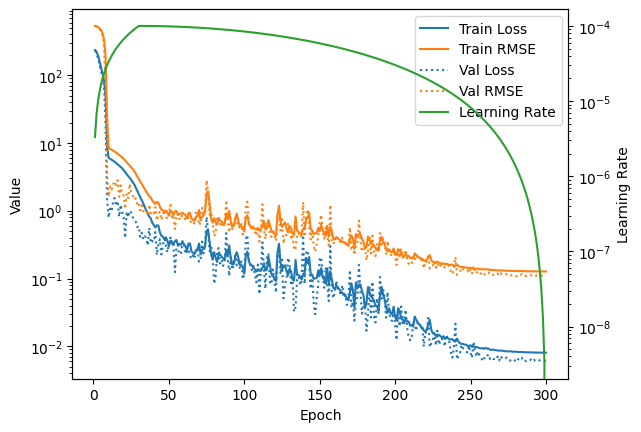

In [ ]:
n = np.arange(1, EPOCHS+1)
metrics = {k: [float(i) for i in v] for k, v in train_metrics.items()}

fig, ax1 = plt.subplots()

ax1.plot(n, metrics["train_loss"], "C0", label="Train Loss")
ax1.plot(n, metrics["train_rmse"], "C1", label="Train RMSE")

ax1.plot(n, metrics["val_loss"], "C0:", label="Val Loss")
ax1.plot(n, metrics["val_rmse"], "C1:", label="Val RMSE")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Value")
ax1.set_yscale("log")

ax2 = ax1.twinx()

ax2.plot(n, metrics["lr"], "C2-", label="Learning Rate")
ax2.set_ylabel("Learning Rate")
ax2.set_yscale("log")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()